In [1]:
import lecilab_behavior_analysis.utils as utils
import lecilab_behavior_analysis.df_transforms as dft
import lecilab_behavior_analysis.plots as plots
from pathlib import Path
import pandas as pd
import numpy as np
from IPython.display import clear_output
import time
import os
from matplotlib import pyplot as plt
import seaborn as sns

%load_ext autoreload
%autoreload 2

In [2]:
# see the available projects
tv_projects = utils.get_server_projects()
for i, p in enumerate(tv_projects):
    print(f"[{i}] {p}")

[0] auditory_escape_data
[1] cate_task_data
[2] COT_cannula_data
[3] COT_test_data
[4] dual2AFC_iDisco_data
[5] empty-project_data
[6] visual_and_COT_data


In [3]:
# select a project
project = tv_projects[0]
print(f"Selected project: {project}")

Selected project: auditory_escape_data


In [4]:
# see the available animals
animals = utils.get_animals_in_project(project)
print(animals)

['ACV011', 'ACV012', 'ACV013', 'ACV014', 'ACV015', 'ACV016', 'ACV017', 'ACV018', 'ACV019', 'ACV020', 'ACV021', 'ACV022', 'NUO020', 'NUO021', 'NUO022', 'NUO023', 'NUO024', 'NUO025', 'NUO026', 'NUO029', 'NUO030', 'NUO031', 'NUO032', 'test01', 'test02', 'test03', 'test04', 'test05', 'testdd', 'videotest']


In [ ]:
# select animals
animals = animals[0:5]
print(f"Selected animals: {animals}")

Selected animals: ['ACV011', 'ACV012']


In [6]:
# retrieve the data for the remaining animals
for mouse in animals:
    local_path = Path(utils.get_outpath()) / Path(project) / Path("sessions") / Path(mouse)
    # create the directory if it doesn't exist
    local_path.mkdir(parents=True, exist_ok=True)
    # download the session data
    utils.rsync_cluster_data(
        project_name=project,
        file_path="sessions/{}/{}.csv".format(mouse, mouse),
        local_path=str(local_path),
        credentials=utils.get_idibaps_cluster_credentials(),
    )
# Clear the output of the jupyter cell
clear_output(wait=True)
time.sleep(.5)
print("Data downloaded successfully.")

Data downloaded successfully.


In [7]:
# download the videos csv files
# retrieve the data for the remaining animals
for mouse in animals:
    local_path = Path(utils.get_outpath()) / Path(project) / Path("videos") / Path(mouse)
    # create the directory if it doesn't exist
    local_path.mkdir(parents=True, exist_ok=True)
    # download the session data
    utils.rsync_cluster_data(
        project_name=project,
        file_path="videos/{}/".format(mouse),
        local_path=str(local_path),
        credentials=utils.get_idibaps_cluster_credentials(),
        # exclude=["*.mp4"],
    )
# Clear the output of the jupyter cell
clear_output(wait=True)
time.sleep(.5)
print("Data downloaded successfully.")

Data downloaded successfully.


In [24]:
# read data for first animal
mouse = animals[1]
local_path = Path(utils.get_outpath()) / Path(project) / Path("sessions") / Path(mouse)
df_beh = pd.read_csv(local_path / Path(f'{mouse}.csv'), sep=";")

In [25]:
# check the video sessions
video_path = local_path.parent.parent / Path("videos") / Path(mouse)
videos = os.listdir(video_path)

In [26]:
# load the first video session and subselect the relevant behavioral data
# select a session
ses_sel = df_beh['date'].unique()[0]
dfsel = df_beh[df_beh['date'] == ses_sel]
# format ses_sel to match video file naming: YYYYMMDD_HHMMSS
ses_sel_fmt = ses_sel.replace("-", "").replace(" ", "_").replace(":", "")
# read the video file
video_file = [v for v in videos if ses_sel_fmt in v][0]
video_path_file = video_path / Path(video_file)
df_vid = pd.read_csv(video_path_file.with_suffix('.csv'), sep=";")

In [27]:
# flatten the items in the sound_played column
sp_ts = [item for sublist in dfsel['sound_played'].dropna().apply(eval) for item in sublist]
nsp_ts = [item for sublist in dfsel['sound_not_played'].dropna().apply(eval) for item in sublist]

In [33]:
def get_trajectory_and_speed(df_vid, timestamp, pre_window=2, post_window=10):
    from_ts = timestamp - pre_window  # pre_window seconds before
    to_ts = timestamp + post_window   # post_window seconds after

    # find the index of the closest frame in the video data
    idx_fromts = (np.abs(df_vid['pre_process_timestamp'] - from_ts)).idxmin()
    idx_tots = (np.abs(df_vid['pre_process_timestamp'] - to_ts)).idxmin()

    # get the xy coordinates for the selected time window
    df_vid_window = df_vid.iloc[idx_fromts: idx_tots][['x_position', 'y_position', 'frame']]

    # calculate the speed as the derivative of the position, removing the -1s
    df_vid_window = df_vid_window[df_vid_window['x_position'] != -1]
    df_vid_window['speed'] = np.sqrt(df_vid_window['x_position'].diff()**2 + df_vid_window['y_position'].diff()**2)
    return df_vid_window

In [44]:
ts_test

1769418965.9774594

In [45]:
dfsel

,session,date,trial,subject,task,system_name,run_mode,TRIAL_END,TRIAL_START,_Transition_to_animal_inside_trigger_zone,_Transition_to_animal_outside_trigger_zone,_Transition_to_sound_triggered,animal_entered_trigger_zone,animal_exited_trigger_zone,ordered_list_of_events,sound_not_played,sound_played,trial_end
0,1,2026-01-26 09:46:47,1,ACV012,EscapeBehavior,village03,Manual,1.769418e+09,1.769418e+09,"[1769417774.1228466, 1769417791.4500942, 17694...","[1769417747.798198, 1769417779.7872238, 176941...",[1769418188.6122782],"[1769417774.122802, 1769417791.4500525, 176941...","[1769417779.7871716, 1769417797.4146163, 17694...","['_Transition_to_animal_outside_trigger_zone',...","[1769417774.1562219, 1769417937.5995543, 17694...",[1769418188.612232],[1769418203.6457121]
1,1,2026-01-26 09:46:47,2,ACV012,EscapeBehavior,village03,Manual,1.769418e+09,1.769418e+09,"[1769418329.5634005, 1769418347.523958, 176941...","[1769418323.6655426, 1769418335.1279411, 17694...",[1769418449.6223905],"[1769418329.563374, 1769418347.5239282, 176941...","[1769418335.1279123, 1769418369.0833533, 17694...","['_Transition_to_animal_outside_trigger_zone',...",[1769418329.597298],[1769418449.6223426],[1769418464.6560388]
2,1,2026-01-26 09:46:47,3,ACV012,EscapeBehavior,village03,Manual,1.769419e+09,1.769418e+09,"[1769418584.6753094, 1769418636.4576418, 17694...","[1769418586.5413504, 1769418640.8891969, 17694...",[1769418704.7332492],"[1769418636.4574, 1769418650.753021, 176941870...","[1769418586.5412977, 1769418640.8891678, 17694...","['_Transition_to_animal_inside_trigger_zone', ...",[1769418584.7086053],[1769418704.7332292],[1769418719.7666082]
3,1,2026-01-26 09:46:47,4,ACV012,EscapeBehavior,village03,Manual,1.769419e+09,1.769419e+09,"[1769418839.7871559, 1769418878.5409431, 17694...","[1769418842.2524369, 1769418886.537914, 176941...",[1769418965.9774814],"[1769418878.5409186, 1769418943.784371, 176941...","[1769418842.2524076, 1769418886.537869, 176941...","['_Transition_to_animal_inside_trigger_zone', ...",[1769418839.82043],[1769418965.9774594],[1769418981.01071]
4,1,2026-01-26 09:46:47,5,ACV012,EscapeBehavior,village03,Manual,1.769420e+09,1.769419e+09,"[1769419110.626743, 1769419133.9858246, 176941...","[1769419101.0301976, 1769419123.5893621, 17694...",[1769419533.3467417],"[1769419110.6266544, 1769419133.985784, 176941...","[1769419123.589316, 1769419139.849953, 1769419...","['_Transition_to_animal_outside_trigger_zone',...","[1769419110.6599631, 1769419230.6852164, 17694...",[1769419533.3467185],[1769419548.3798616]
5,1,2026-01-26 09:46:47,6,ACV012,EscapeBehavior,village03,Manual,1.769420e+09,1.769420e+09,[1769419668.3998554],NaN,[1769419668.4333673],NaN,NaN,"['_Transition_to_animal_inside_trigger_zone', ...",NaN,[1769419668.4333258],[1769419683.466546]
6,1,2026-01-26 09:46:47,7,ACV012,EscapeBehavior,village03,Manual,1.769420e+09,1.769420e+09,"[1769419845.271979, 1769419874.0616453, 176941...","[1769419803.4865406, 1769419849.3704057, 17694...",[1769419977.792803],"[1769419845.2719443, 1769419874.061617, 176941...","[1769419849.3703284, 1769419879.9941866, 17694...","['_Transition_to_animal_outside_trigger_zone',...",[1769419845.3060865],[1769419977.7927783],[1769419992.826384]
7,1,2026-01-26 09:46:47,8,ACV012,EscapeBehavior,village03,Manual,1.769420e+09,1.769420e+09,[1769420125.508467],[1769420112.8451273],[1769420125.5418453],[1769420125.508416],NaN,"['_Transition_to_animal_outside_trigger_zone',...",NaN,[1769420125.5418174],[1769420140.5751483]


In [42]:
from_ts = ts_test - 2  # pre_window seconds before
to_ts = ts_test + 10   # post_window seconds after

# find the index of the closest frame in the video data
idx_fromts = (np.abs(df_vid['pre_process_timestamp'] - from_ts)).idxmin()
idx_tots = (np.abs(df_vid['pre_process_timestamp'] - to_ts)).idxmin()

# get the xy coordinates for the selected time window
df_vid.iloc[idx_fromts: idx_tots][['x_position', 'y_position', 'frame']]

,x_position,y_position,frame
52703,-1,-1,52704
52704,-1,-1,52705
52705,-1,-1,52706
52706,-1,-1,52707
52707,-1,-1,52708
...,...,...,...
53058,-1,-1,53059
53059,-1,-1,53060
53060,-1,-1,53061
53061,-1,-1,53062


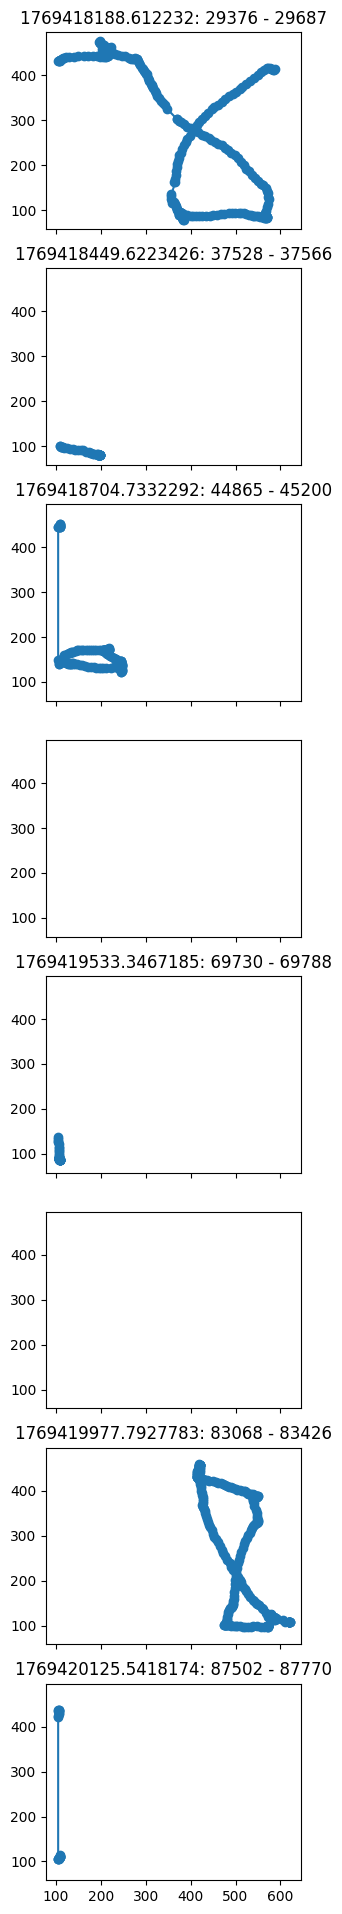

In [47]:
fig, axes = plt.subplots(len(sp_ts), 1, figsize=(10, 3 * len(sp_ts)), sharex=True, sharey=True)
for i, ts in enumerate(sp_ts):
    df_vid_window = get_trajectory_and_speed(df_vid, ts)
    # remove rows where speed is over 70
    # df_vid_window = df_vid_window[df_vid_window['speed'] <= 70]
    # plot the trajectory
    axes[i].plot(df_vid_window['x_position'], df_vid_window['y_position'], marker='o')
    axes[i].set_aspect('equal', adjustable='box')
    if df_vid_window.shape[0] > 0:
        axes[i].set_title(f"{ts}: {df_vid_window['frame'].iloc[0]} - {df_vid_window['frame'].iloc[-2]}")

plt.show()


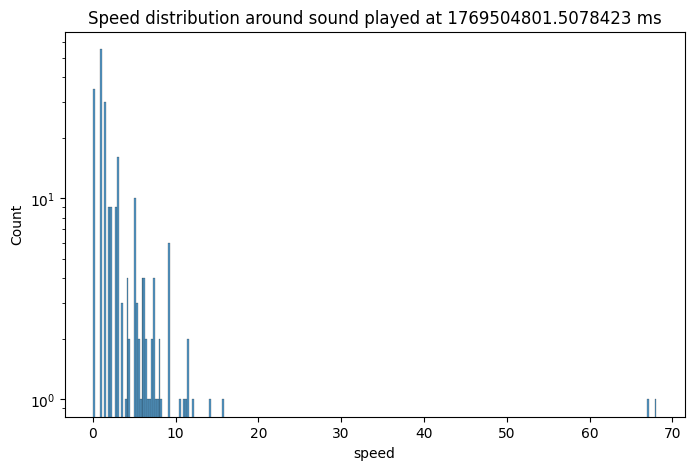

In [64]:
# show a histogram of the speed 
plt.figure(figsize=(8, 5))
sns.histplot(df_vid_window['speed'].dropna(), bins=300)
plt.title(f'Speed distribution around sound played at {timestamp} ms')
# y axis log
plt.yscale('log')

In [65]:
# remove rows where speed is over 70
df_vid_window = df_vid_window[df_vid_window['speed'] <= 70]

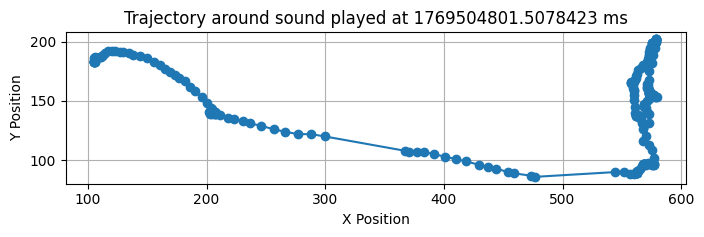

In [83]:
# plot the trajectory
plt.figure(figsize=(8, 8))
plt.plot(df_vid_window['x_position'], df_vid_window['y_position'], marker='o')
plt.gca().set_aspect('equal', adjustable='box')
plt.title(f'Trajectory around sound played at {timestamp} ms')
plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.grid()
plt.show()


In [81]:
#make the x_position and the y_position as numerical
df_vid_window['x_position'] = pd.to_numeric(df_vid_window['x_position'], errors='coerce')
df_vid_window['y_position'] = pd.to_numeric(df_vid_window['y_position'], errors='coerce')

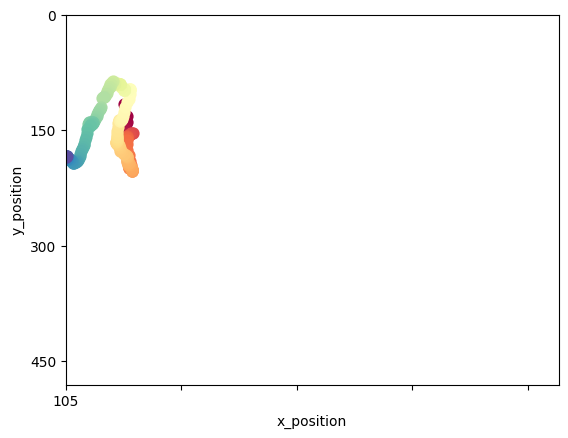

In [82]:
# make a lineplot showing the trajectory over time, with color indicating the time
sns.pointplot(x="x_position", y="y_position", data=df_vid_window, hue=df_vid_window.index, legend=False, palette='Spectral')
plt.xlim(0, 640)
plt.ylim(0, 480)
plt.gca().invert_yaxis()  # Invert y-axis to match typical video coordinate system
# set the ticks to be every 100 pixels
plt.xticks(np.arange(0, 641, 150))
plt.yticks(np.arange(0, 481, 150))
plt.gca().set_aspect('equal', adjustable='box')

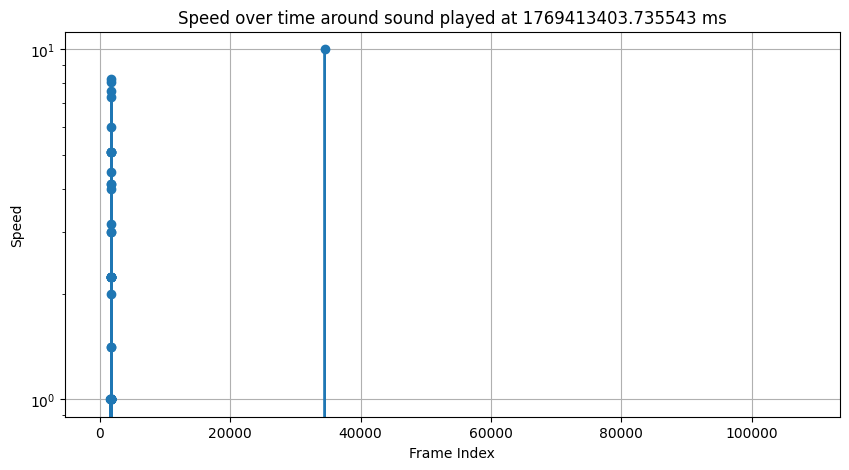

In [19]:
# plot speed over time
plt.figure(figsize=(10, 5))
plt.plot(df_vid_window.index, df_vid_window['speed'], marker='o')
plt.title(f'Speed over time around sound played at {timestamp} ms')
plt.xlabel('Frame Index')
plt.ylabel('Speed')
plt.grid()
plt.yscale('log')
plt.show()
